# 🤖 Taller XAI: Ética, Sesgo y Calidad en el Aprendizaje Automático
## MIAR0525 · Semana 4 · Portfolio Técnico Completo

---

**Maestría en Inteligencia Artificial — Curso Machine Learning**

| Nombre | Rol |
|--------|-----|
| Daniel Fernando Salgado Santamaría | Modelado, SHAP Analysis |
| Jairo Wladimir Jhayya Perlaza | LIME Analysis, Fairness Metrics |
| Luis Gabriel Salgado Santamaría | Data Quality, Bias Detection |
| Oscar Paul Naranjo Castro | Bias Mitigation, Ethical Analysis |

---

### Objetivos
1. Implementar un modelo supervisado con análisis de **calidad de datos y mitigación de sesgos**
2. Aplicar **≥3 técnicas XAI**: SHAP, LIME, Permutation Feature Importance
3. Medir **equidad** con Fairlearn (DPD, EOD)
4. Redactar un **análisis ético reflexivo** fundamentado

### Dataset
**Adult Income (UCI)** — Predice ingresos > USD 50K/año. Fuente: Censo EE.UU. 1994.  
Especialmente relevante para estudiar sesgo por contener atributos protegidos: género y raza.


## ⚙️ 0. Instalación e Importaciones

In [50]:
# Instalar librerías necesarias (ejecutar solo si no están instaladas)
!pip install shap lime fairlearn --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import os

# Crear figures/ en todos los lugares posibles
os.makedirs('figures', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

print(f"Directorio actual: {os.getcwd()}")
print("✔ Carpeta figures/ lista")

Directorio actual: g:\ProyectosPython\proyecto4\desarrollo4\ml-xai-ethics-portfolio\notebooks
✔ Carpeta figures/ lista


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, RocCurveDisplay
)

# XAI
import shap
import lime
import lime.lime_tabular

# Fairness
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference,
    equalized_odds_difference, selection_rate
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

# ── Configuración visual ──────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#8B1A2F', '#C0392B', '#A9CCE3', '#5D6D7E', '#D5D8DC']
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13})
SEED = 42
np.random.seed(SEED)
print("✅ Librerías importadas correctamente.")
import sklearn; print(f"   scikit-learn {sklearn.__version__} | shap {shap.__version__}")

✅ Librerías importadas correctamente.
   scikit-learn 1.8.0 | shap 0.51.0


---
## 📊 Parte 1: Carga y Auditoría de Calidad de Datos

In [53]:
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
COLUMNAS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]
df_raw = pd.read_csv(URL, header=None, names=COLUMNAS,
                     na_values=' ?', skipinitialspace=True)
print(f"📐 Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

📐 Dimensiones: 32,561 filas × 15 columnas


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


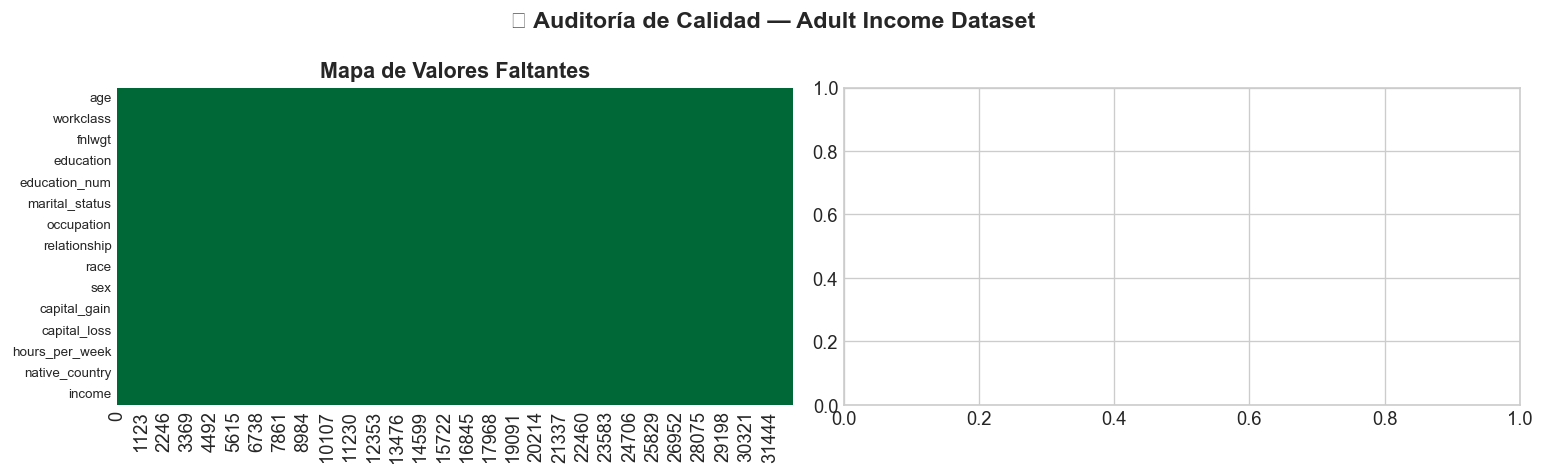

Registros completos: 32,561 | Duplicados: 24
Empty DataFrame
Columns: [Nulos, % del total]
Index: []


In [54]:
# ── Auditoría de calidad ──────────────────────────────────────────────────────
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
auditoria = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
auditoria = auditoria[auditoria['Nulos'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(df_raw.isnull().T, cbar=False, cmap='RdYlGn_r', ax=axes[0])
axes[0].set_title('Mapa de Valores Faltantes', fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)

if not auditoria.empty:
    auditoria['% del total'].plot(kind='barh', color='#8B1A2F', ax=axes[1])
    axes[1].set_title('% de Valores Faltantes por Columna', fontweight='bold')
    for i, v in enumerate(auditoria['% del total']):
        axes[1].text(v + 0.02, i, f'{v}%', va='center', fontsize=10)
plt.suptitle('🔍 Auditoría de Calidad — Adult Income Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_data_quality_audit.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Registros completos: {df_raw.dropna().shape[0]:,} | Duplicados: {df_raw.duplicated().sum()}")
print(auditoria.to_string())

In [55]:
# ── Limpieza de datos ─────────────────────────────────────────────────────────
df = df_raw.copy()
for col in ['workclass', 'occupation', 'native_country']:
    moda = df[col].mode()[0]
    n_na = df[col].isnull().sum()
    df[col].fillna(moda, inplace=True)
    print(f"  ✔ '{col}': {n_na} nulos → moda='{moda}'")
n_antes = len(df)
df.drop_duplicates(inplace=True); df.reset_index(drop=True, inplace=True)
print(f"  ✔ Duplicados eliminados: {n_antes - len(df)}")
print(f"  ✔ Dataset final: {len(df):,} registros, {df.isnull().sum().sum()} nulos")

  ✔ 'workclass': 0 nulos → moda='Private'
  ✔ 'occupation': 0 nulos → moda='Prof-specialty'
  ✔ 'native_country': 0 nulos → moda='United-States'
  ✔ Duplicados eliminados: 24
  ✔ Dataset final: 32,537 registros, 0 nulos


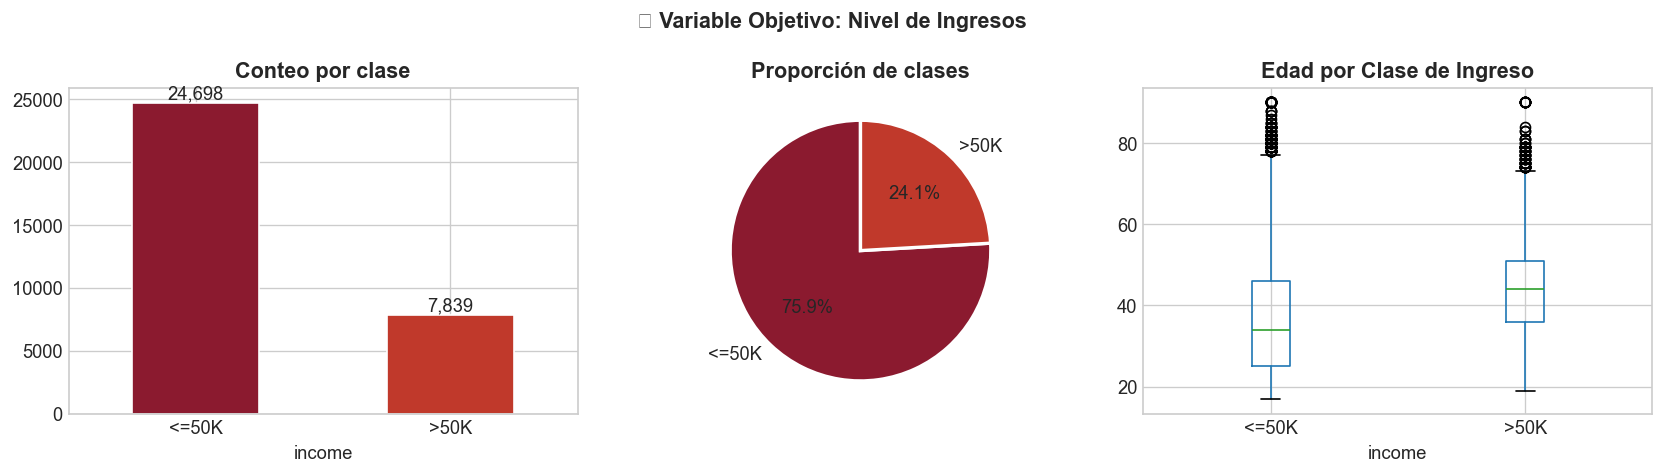

Desbalance: 75.9% (≤50K) vs 24.1% (>50K)


In [56]:
# ── Distribución de la variable objetivo ─────────────────────────────────────
conteo = df['income'].value_counts()
pct = (conteo / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
conteo.plot(kind='bar', ax=axes[0], color=COLORS[:2], edgecolor='white', width=0.5)
axes[0].set_title('Conteo por clase', fontweight='bold')
axes[0].tick_params(rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
            colors=COLORS[:2], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de clases', fontweight='bold')

df.boxplot(column='age', by='income', ax=axes[2])
axes[2].set_title('Edad por Clase de Ingreso', fontweight='bold')
plt.suptitle('')
plt.suptitle('📈 Variable Objetivo: Nivel de Ingresos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Desbalance: {pct.iloc[0]}% (≤50K) vs {pct.iloc[1]}% (>50K)")

---
## ⚠️ Parte 2: Detección de Sesgos en los Datos

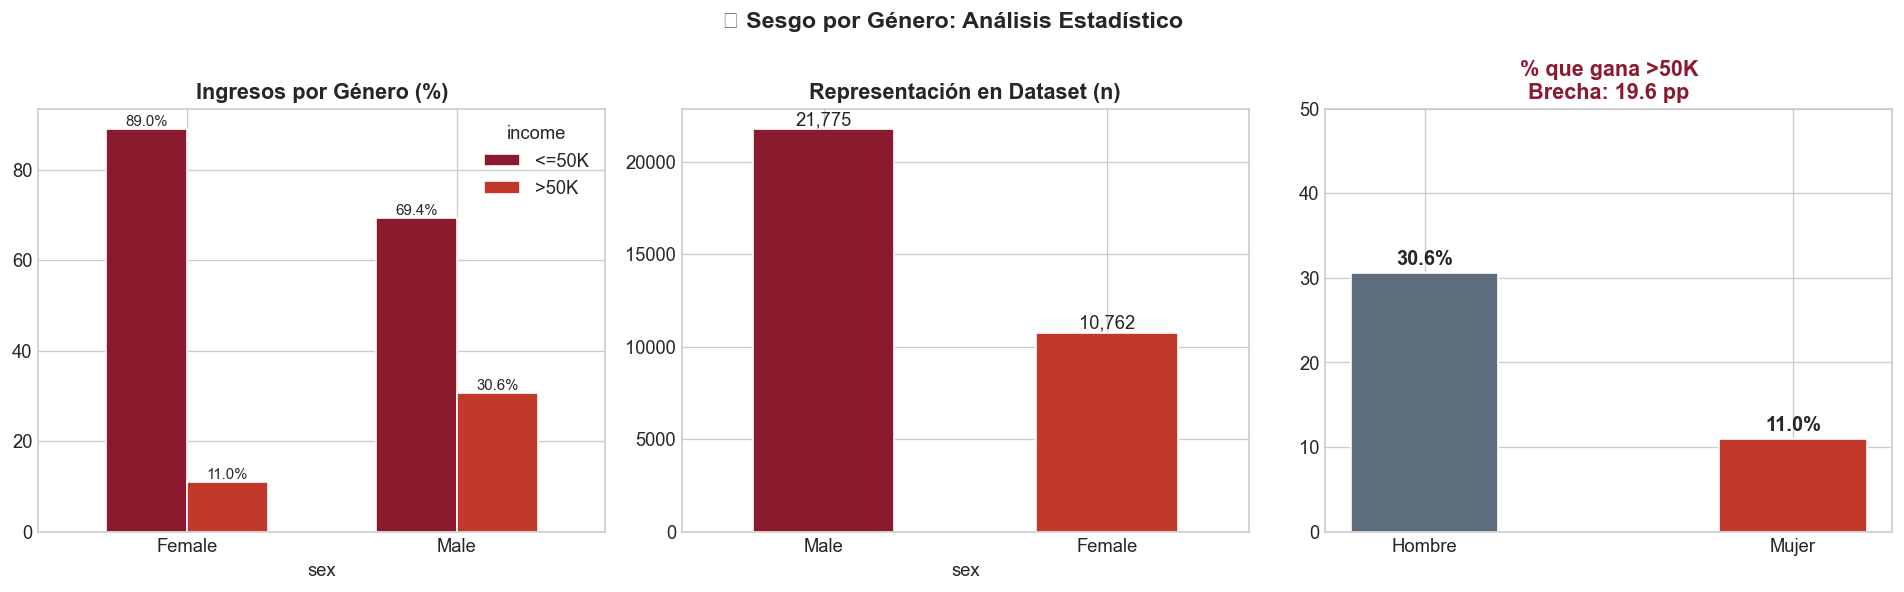

Brecha de género en el dataset: 19.6 pp


In [57]:
# ── Sesgo por género ──────────────────────────────────────────────────────────
income_sex = df.groupby(['sex', 'income']).size().unstack(fill_value=0)
income_sex_pct = income_sex.div(income_sex.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
income_sex_pct.plot(kind='bar', ax=axes[0], color=COLORS[:2], edgecolor='white', width=0.6)
axes[0].set_title('Ingresos por Género (%)', fontweight='bold')
axes[0].tick_params(rotation=0)
for p in axes[0].patches:
    h = p.get_height()
    if h > 1:
        axes[0].annotate(f'{h:.1f}%', (p.get_x()+p.get_width()/2., h),
                         ha='center', va='bottom', fontsize=9)

df['sex'].value_counts().plot(kind='bar', ax=axes[1], color=COLORS[:2], edgecolor='white', width=0.5)
axes[1].set_title('Representación en Dataset (n)', fontweight='bold')
axes[1].tick_params(rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

hombre_50k = income_sex_pct.loc['Male', '>50K']
mujer_50k = income_sex_pct.loc['Female', '>50K']
brecha = hombre_50k - mujer_50k
bars = axes[2].bar(['Hombre', 'Mujer'], [hombre_50k, mujer_50k],
                    color=['#5D6D7E', '#C0392B'], edgecolor='white', width=0.4)
axes[2].set_title(f'% que gana >50K\nBrecha: {brecha:.1f} pp', fontweight='bold', color='#8B1A2F')
axes[2].set_ylim(0, 50)
for bar, val in zip(bars, [hombre_50k, mujer_50k]):
    axes[2].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.suptitle('🚨 Sesgo por Género: Análisis Estadístico', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_gender_bias.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Brecha de género en el dataset: {brecha:.1f} pp")

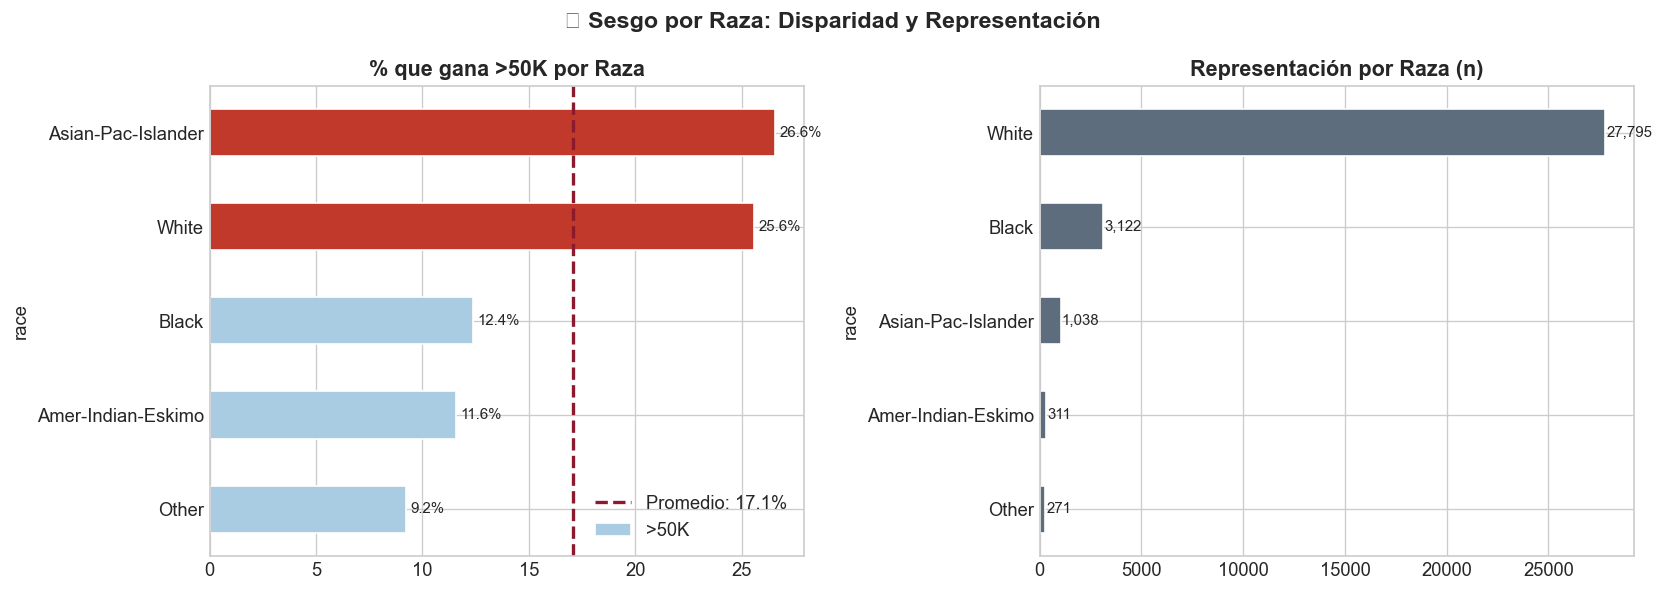

In [58]:
# ── Sesgo por raza ────────────────────────────────────────────────────────────
income_race = df.groupby(['race', 'income']).size().unstack(fill_value=0)
income_race_pct = income_race.div(income_race.sum(axis=1), axis=0) * 100
promedio_raza = income_race_pct['>50K'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_raza = ['#C0392B' if v > promedio_raza else '#A9CCE3'
               for v in income_race_pct['>50K'].sort_values()]
income_race_pct['>50K'].sort_values().plot(kind='barh', ax=axes[0], color=colors_raza, edgecolor='white')
axes[0].axvline(promedio_raza, color='#8B1A2F', linestyle='--', linewidth=2,
               label=f'Promedio: {promedio_raza:.1f}%')
axes[0].set_title('% que gana >50K por Raza', fontweight='bold')
axes[0].legend()
for i, (idx, val) in enumerate(income_race_pct['>50K'].sort_values().items()):
    axes[0].text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)

income_race.sum(axis=1).sort_values().plot(kind='barh', ax=axes[1], color='#5D6D7E', edgecolor='white')
axes[1].set_title('Representación por Raza (n)', fontweight='bold')
for i, (idx, val) in enumerate(income_race.sum(axis=1).sort_values().items()):
    axes[1].text(val + 50, i, f'{val:,}', va='center', fontsize=9)

plt.suptitle('🚨 Sesgo por Raza: Disparidad y Representación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/04_race_bias.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🤖 Parte 3: Preprocesamiento y Entrenamiento del Modelo

In [59]:
# ── Preprocesamiento ──────────────────────────────────────────────────────────
df_model = df.copy()
sensitive_attr = df_model['sex'].map({'Male': 1, 'Female': 0})
df_model['target'] = (df_model['income'] == '>50K').astype(int)

FEATURES = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss',
            'workclass', 'marital_status', 'occupation', 'relationship']

le = LabelEncoder()
for col in ['workclass', 'marital_status', 'occupation', 'relationship']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model[FEATURES]
y = df_model['target']
X_train, X_test, y_train, y_test, sa_train, sa_test = train_test_split(
    X, y, sensitive_attr, test_size=0.20, random_state=SEED, stratify=y)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Features: {X_train.shape[1]}")

Train: 26,029 | Test: 6,508 | Features: 9


In [60]:
# ── Entrenamiento Random Forest ───────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                             class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)

print("📊 REPORTE DE CLASIFICACIÓN — Random Forest")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['≤50K', '>50K']))
print(f"AUC-ROC: {auc:.4f}")

📊 REPORTE DE CLASIFICACIÓN — Random Forest
              precision    recall  f1-score   support

        ≤50K       0.96      0.79      0.87      4940
        >50K       0.58      0.89      0.70      1568

    accuracy                           0.81      6508
   macro avg       0.77      0.84      0.78      6508
weighted avg       0.86      0.81      0.83      6508

AUC-ROC: 0.9231


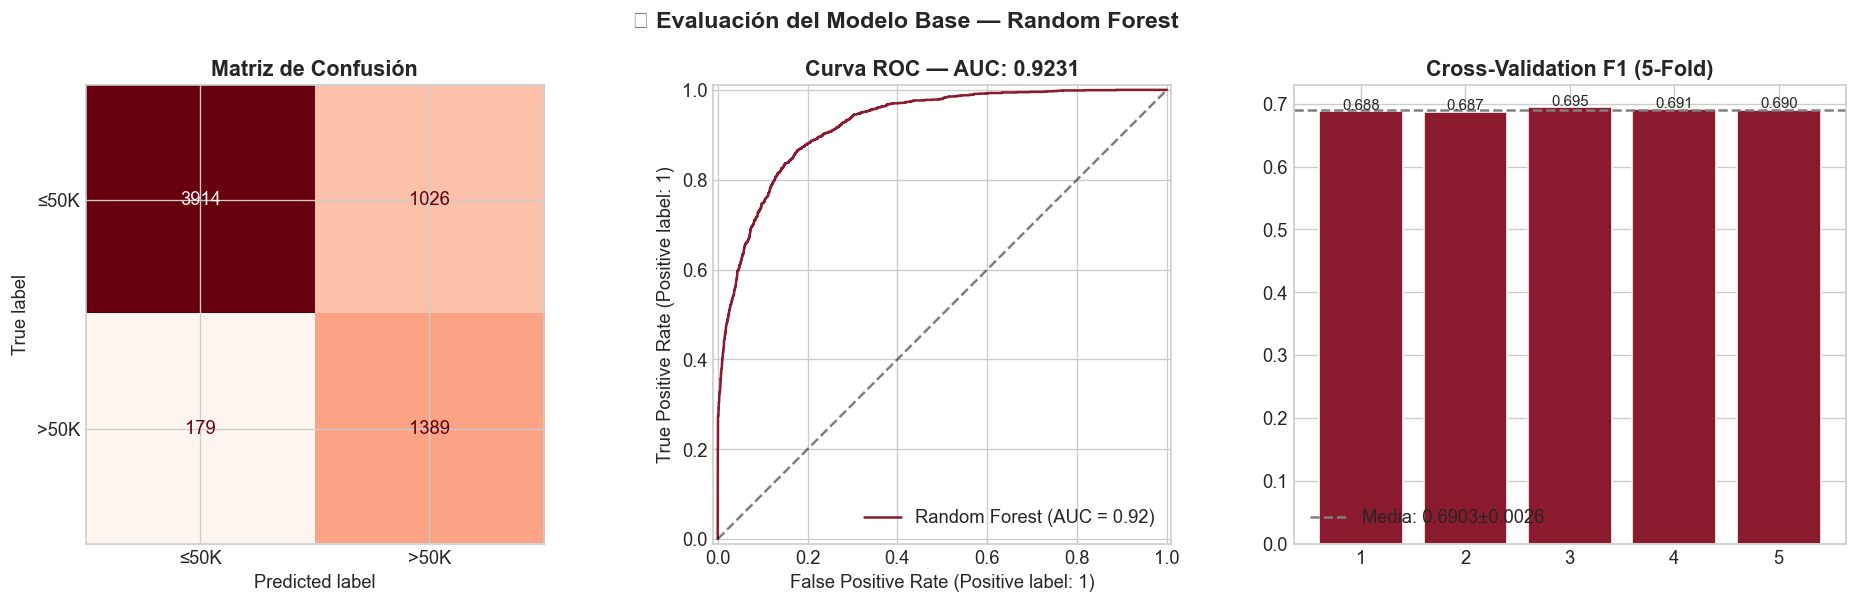

In [61]:
# ── Visualización de evaluación ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['≤50K', '>50K'],
                                         cmap='Reds', colorbar=False, ax=axes[0])
axes[0].set_title('Matriz de Confusión', fontweight='bold')

RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1],
                                  color='#8B1A2F', name='Random Forest')
axes[1].plot([0,1],[0,1],'k--',alpha=0.5)
axes[1].set_title(f'Curva ROC — AUC: {auc:.4f}', fontweight='bold')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1')
axes[2].bar(range(1,6), cv_scores, color='#8B1A2F', edgecolor='white')
axes[2].axhline(cv_scores.mean(), color='gray', linestyle='--',
               label=f'Media: {cv_scores.mean():.4f}±{cv_scores.std():.4f}')
axes[2].set_title('Cross-Validation F1 (5-Fold)', fontweight='bold')
axes[2].legend()
for i, v in enumerate(cv_scores):
    axes[2].text(i+1, v+0.003, f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('📈 Evaluación del Modelo Base — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/05_model_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

---
## ⚖️ Parte 4: Métricas de Equidad con Fairlearn

In [62]:
# ── MetricFrame por género ────────────────────────────────────────────────────
metricas = {
    'accuracy': accuracy_score,
    'precision': lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
    'recall': lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
    'f1': lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0),
    'selection_rate': selection_rate
}
mf = MetricFrame(metrics=metricas, y_true=y_test, y_pred=y_pred, sensitive_features=sa_test)
resultado = mf.by_group.rename(index={0: 'Mujer', 1: 'Hombre'})
dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sa_test)
eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sa_test)

print("📊 MÉTRICAS DE EQUIDAD POR GÉNERO")
print("=" * 55)
print(resultado.round(4).to_string())
print(f"|DPD| = {abs(dpd):.4f}  |  |EOD| = {abs(eod):.4f}")
print("→ Un DPD > 0.10 indica disparidad significativa (supera umbral aceptable)")

📊 MÉTRICAS DE EQUIDAD POR GÉNERO
        accuracy  precision  recall      f1  selection_rate
sex                                                        
Mujer     0.9164     0.6152  0.7992  0.6952          0.1549
Hombre    0.7654     0.5688  0.9026  0.6979          0.4762
|DPD| = 0.3213  |  |EOD| = 0.2257
→ Un DPD > 0.10 indica disparidad significativa (supera umbral aceptable)


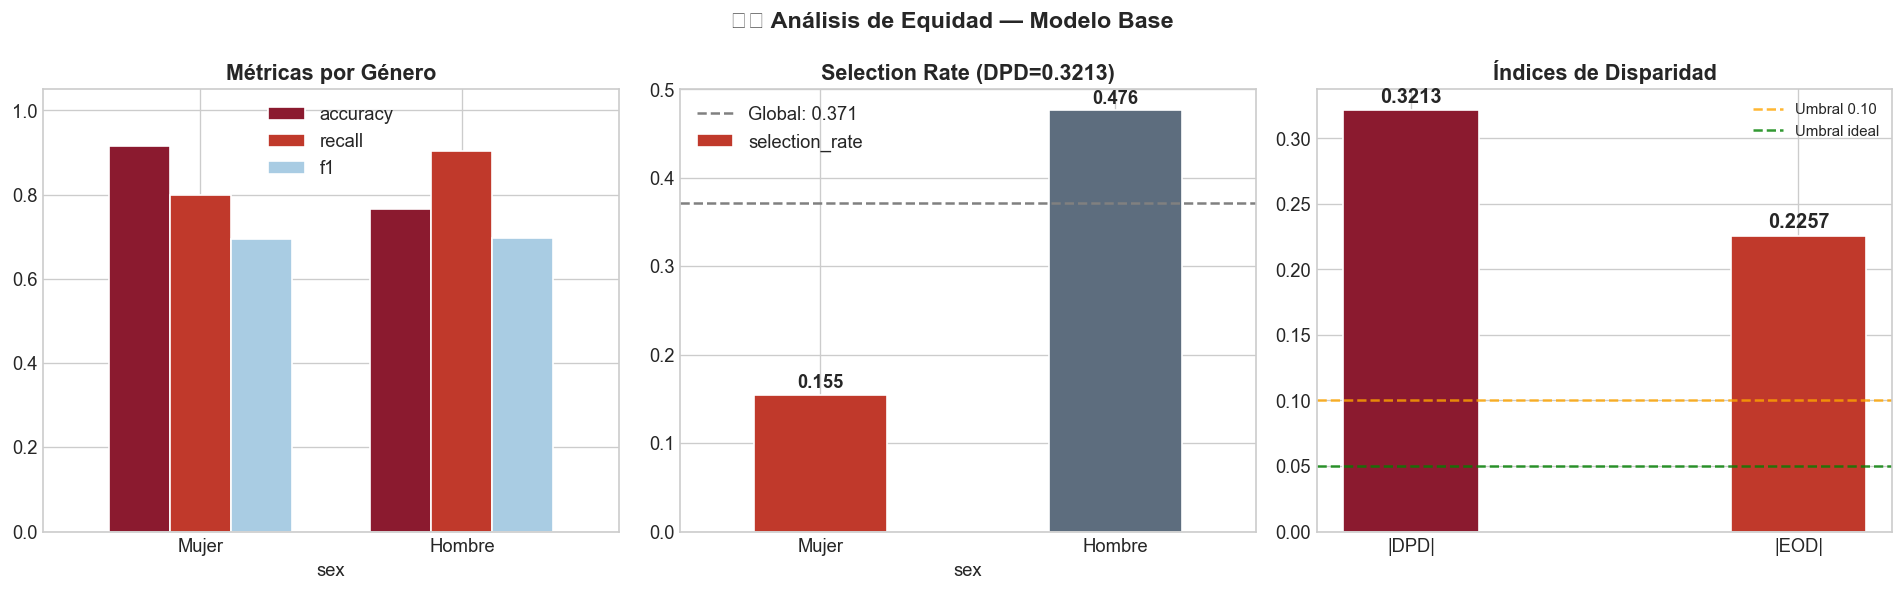

In [63]:
# ── Visualización de equidad ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
resultado[['accuracy','recall','f1']].plot(kind='bar', ax=axes[0],
    color=COLORS[:3], edgecolor='white', width=0.7)
axes[0].set_title('Métricas por Género', fontweight='bold')
axes[0].set_ylim(0, 1.05); axes[0].tick_params(rotation=0)

resultado['selection_rate'].plot(kind='bar', ax=axes[1],
    color=['#C0392B','#5D6D7E'], edgecolor='white', width=0.45)
axes[1].axhline(mf.overall['selection_rate'], color='gray', linestyle='--',
               label=f'Global: {mf.overall["selection_rate"]:.3f}')
axes[1].set_title(f'Selection Rate (DPD={dpd:.4f})', fontweight='bold')
axes[1].tick_params(rotation=0); axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                     (p.get_x()+p.get_width()/2., p.get_height()+0.003),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

bars = axes[2].bar(['|DPD|','|EOD|'], [abs(dpd), abs(eod)],
                   color=['#8B1A2F','#C0392B'], edgecolor='white', width=0.35)
axes[2].axhline(0.10, color='orange', linestyle='--', alpha=0.8, label='Umbral 0.10')
axes[2].axhline(0.05, color='green', linestyle='--', alpha=0.8, label='Umbral ideal')
axes[2].set_title('Índices de Disparidad', fontweight='bold'); axes[2].legend(fontsize=9)
for bar, val in zip(bars, [abs(dpd), abs(eod)]):
    axes[2].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.suptitle('⚖️ Análisis de Equidad — Modelo Base', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/06_fairness_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🔬 Parte 5: Explicabilidad Global y Local con SHAP

In [64]:
# ── Cálculo de valores SHAP ───────────────────────────────────────────────────
print("⏳ Calculando valores SHAP para Random Forest (~30-60s)...")
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Compatible con SHAP antiguo y nuevo
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values
    
mean_abs_shap = np.abs(shap_pos).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=FEATURES).sort_values(ascending=False)
print(f"✅ SHAP calculado. Shape: {shap_pos.shape}")
print(shap_importance.round(4).to_string())

⏳ Calculando valores SHAP para Random Forest (~30-60s)...
✅ SHAP calculado. Shape: (6508, 9)
relationship      0.1292
education_num     0.0949
marital_status    0.0868
age               0.0675
capital_gain      0.0530
hours_per_week    0.0426
occupation        0.0215
capital_loss      0.0142
workclass         0.0041


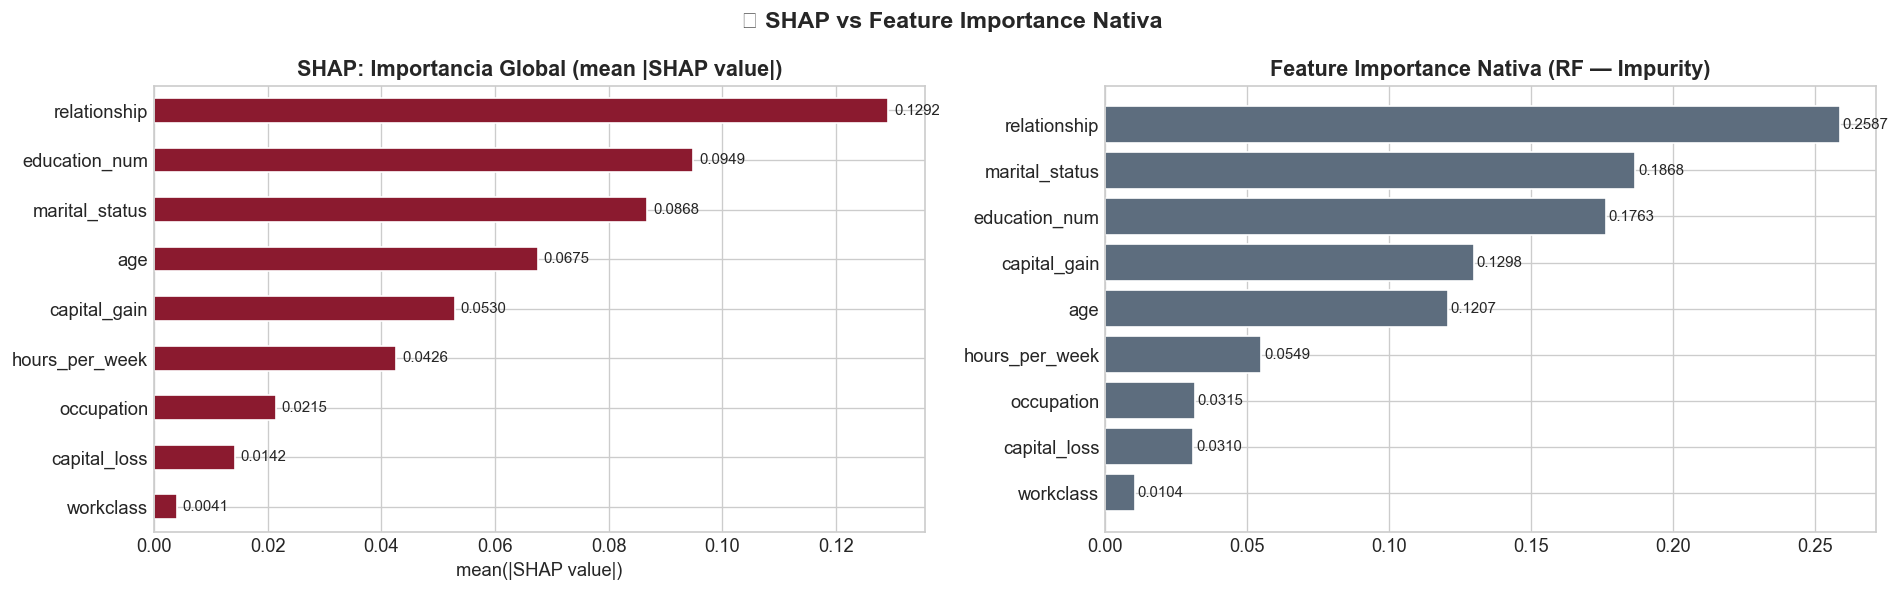

In [65]:
# ── SHAP: Importancia Global ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
shap_importance.plot(kind='barh', ax=axes[0], color='#8B1A2F', edgecolor='white')
axes[0].set_title('SHAP: Importancia Global (mean |SHAP value|)', fontweight='bold')
axes[0].set_xlabel('mean(|SHAP value|)'); axes[0].invert_yaxis()
for i, (idx_f, val) in enumerate(shap_importance.items()):
    axes[0].text(val+0.001, i, f'{val:.4f}', va='center', fontsize=9)

rf_importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
axes[1].barh(range(len(rf_importance)), rf_importance.values, color='#5D6D7E', edgecolor='white')
axes[1].set_yticks(range(len(rf_importance))); axes[1].set_yticklabels(rf_importance.index)
axes[1].set_title('Feature Importance Nativa (RF — Impurity)', fontweight='bold')
axes[1].invert_yaxis()
for i, val in enumerate(rf_importance.values):
    axes[1].text(val+0.001, i, f'{val:.4f}', va='center', fontsize=9)
plt.suptitle('🔬 SHAP vs Feature Importance Nativa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/07_shap_global_importance.png', bbox_inches='tight', dpi=150)
plt.show()

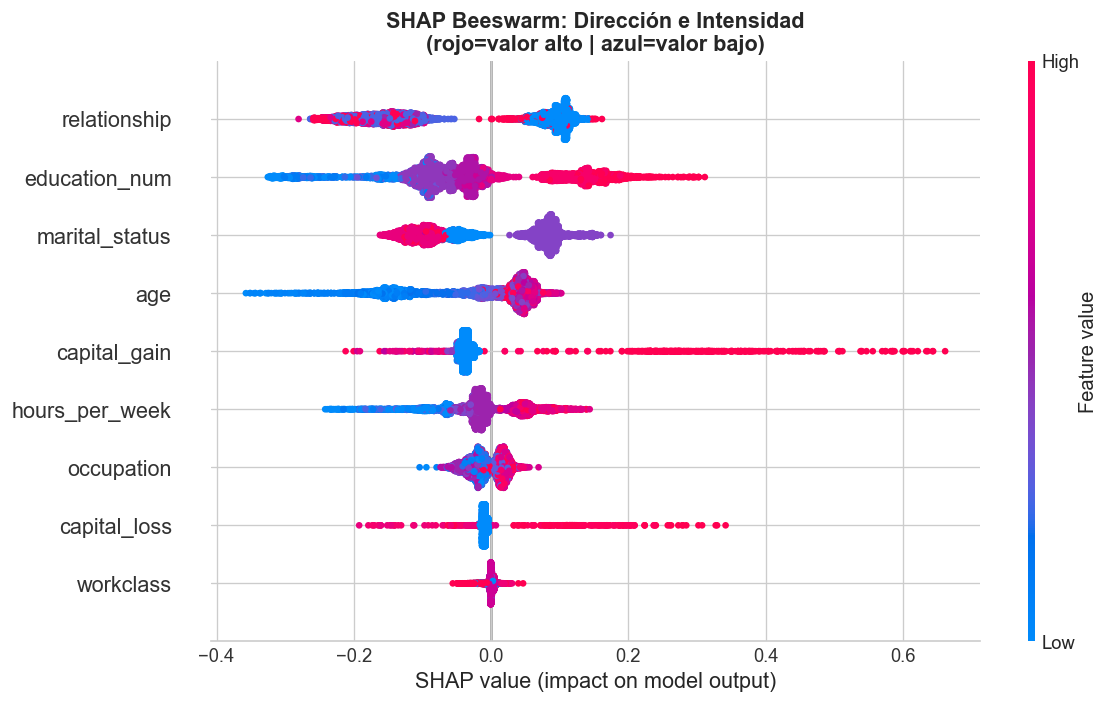

💡 Valores SHAP positivos → empujan hacia >50K | negativos → empujan hacia ≤50K


In [66]:
# ── SHAP Beeswarm (dirección e intensidad) ────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_pos, X_test, show=False, plot_size=None, max_display=9)
plt.title('SHAP Beeswarm: Dirección e Intensidad\n(rojo=valor alto | azul=valor bajo)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/08_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print("💡 Valores SHAP positivos → empujan hacia >50K | negativos → empujan hacia ≤50K")

📌 INSTANCIA #0: Clase=≤ 50K | P(>50K)=0.0886
Características: {'age': 27, 'education_num': 14, 'hours_per_week': 40, 'capital_gain': 0, 'capital_loss': 0, 'workclass': 4, 'marital_status': 4, 'occupation': 7, 'relationship': 1}


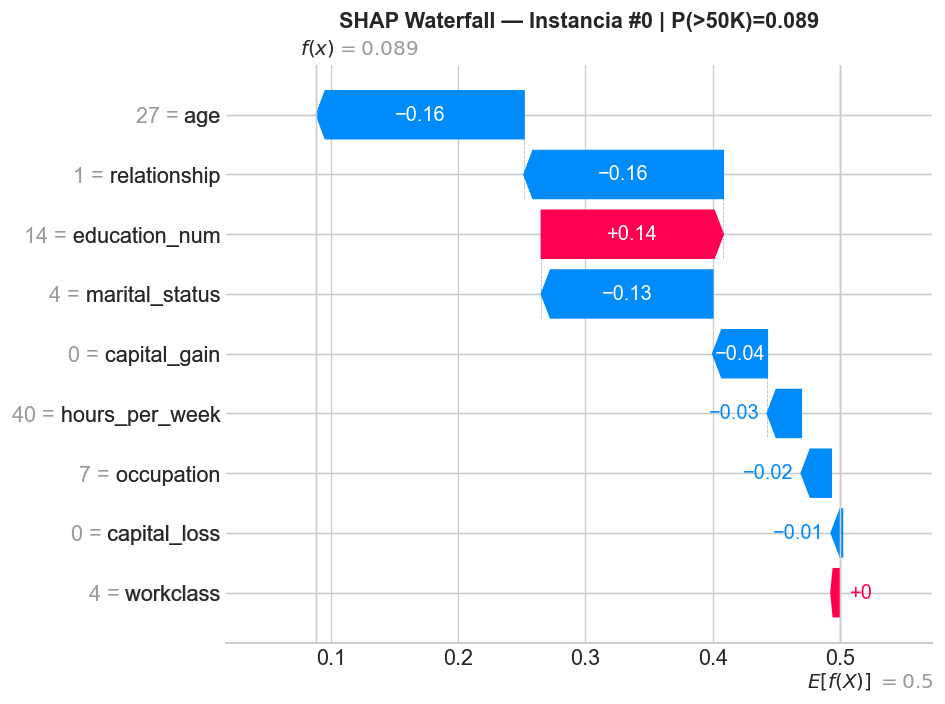

In [68]:
# ── SHAP Waterfall — Instancia 0 ──────────────────────────────────────────────
idx = 0
instancia = X_test.iloc[[idx]]
pred_clase = rf.predict(instancia)[0]
pred_proba = rf.predict_proba(instancia)[0]

print(f"📌 INSTANCIA #{idx}: Clase={'> 50K' if pred_clase else '≤ 50K'} | P(>50K)={pred_proba[1]:.4f}")
print("Características:", instancia.to_dict('records')[0])

base_val = explainer.expected_value
if hasattr(base_val, '__len__'):
    base_val = float(base_val[1])
else:
    base_val = float(base_val)

shap_exp = shap.Explanation(values=shap_pos[idx].astype(float),
                             base_values=base_val,
                             data=instancia.values[0].astype(float),
                             feature_names=FEATURES)
plt.figure(figsize=(9, 5))
shap.waterfall_plot(shap_exp, show=False, max_display=9)
plt.title(f'SHAP Waterfall — Instancia #{idx} | P(>50K)={pred_proba[1]:.3f}', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/09_shap_waterfall_pos.png', bbox_inches='tight', dpi=150)
plt.show()

📌 INSTANCIA #4: Clase=≤ 50K | P(>50K)=0.1686


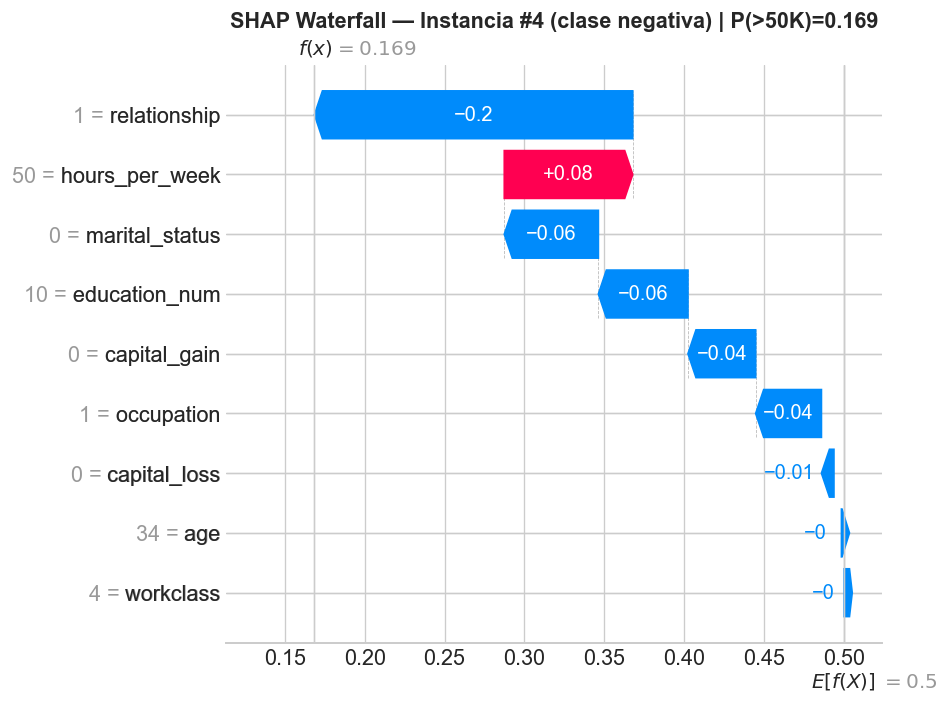

In [69]:
# ── SHAP Waterfall — Instancia negativa (contraste) ─────────────────────────
idx2 = int(np.where(y_test == 0)[0][3])
instancia2 = X_test.iloc[[idx2]]
pred2 = rf.predict(instancia2)[0]
proba2 = rf.predict_proba(instancia2)[0]

print(f"📌 INSTANCIA #{idx2}: Clase={'> 50K' if pred2 else '≤ 50K'} | P(>50K)={proba2[1]:.4f}")
shap_exp2 = shap.Explanation(values=shap_pos[idx2], base_values=base_val,
                              data=instancia2.values[0], feature_names=FEATURES)
plt.figure(figsize=(9, 5))
shap.waterfall_plot(shap_exp2, show=False, max_display=9)
plt.title(f'SHAP Waterfall — Instancia #{idx2} (clase negativa) | P(>50K)={proba2[1]:.3f}',
          fontweight='bold')
plt.tight_layout()
plt.savefig('figures/10_shap_waterfall_neg.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🔬 Parte 6: Explicabilidad Local con LIME

In [70]:
# ── Inicialización LIME ───────────────────────────────────────────────────────
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values, feature_names=FEATURES,
    class_names=['≤50K', '>50K'], mode='classification',
    discretize_continuous=True, random_state=SEED)
print("✅ LIME Explainer inicializado")

✅ LIME Explainer inicializado


⏳ Generando explicación LIME instancia #0...


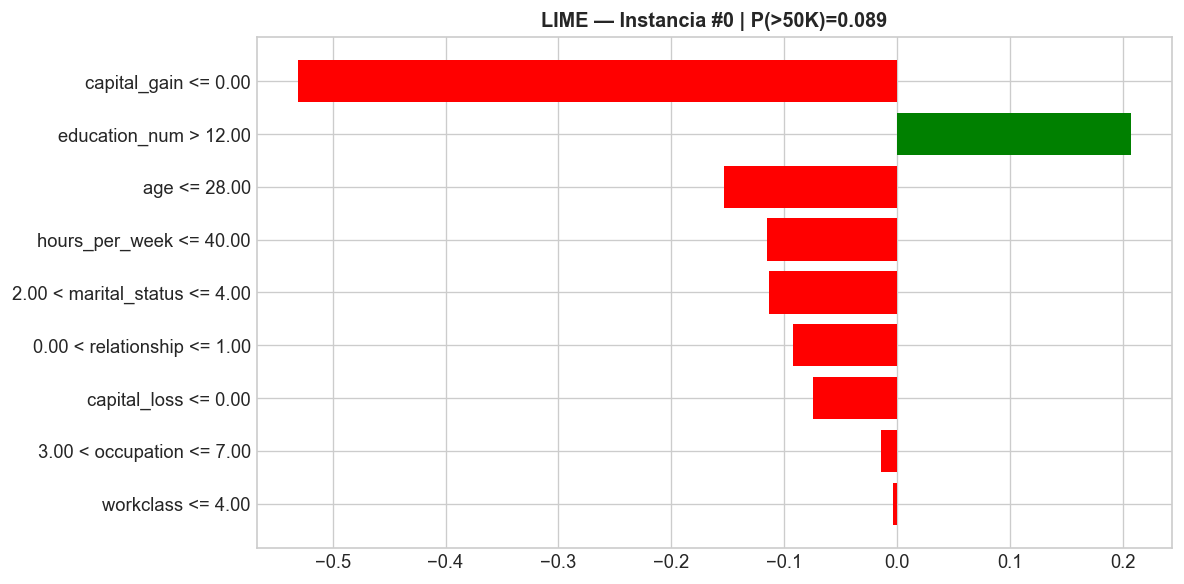

In [71]:
# ── LIME Instancia 0 ──────────────────────────────────────────────────────────
print(f"⏳ Generando explicación LIME instancia #{idx}...")
exp_lime_0 = lime_explainer.explain_instance(X_test.values[idx], rf.predict_proba,
                                              num_features=9, num_samples=3000)
fig = exp_lime_0.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
plt.title(f'LIME — Instancia #{idx} | P(>50K)={pred_proba[1]:.3f}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/11_lime_instance_pos.png', bbox_inches='tight', dpi=150)
plt.show()

⏳ Generando explicación LIME instancia #4...


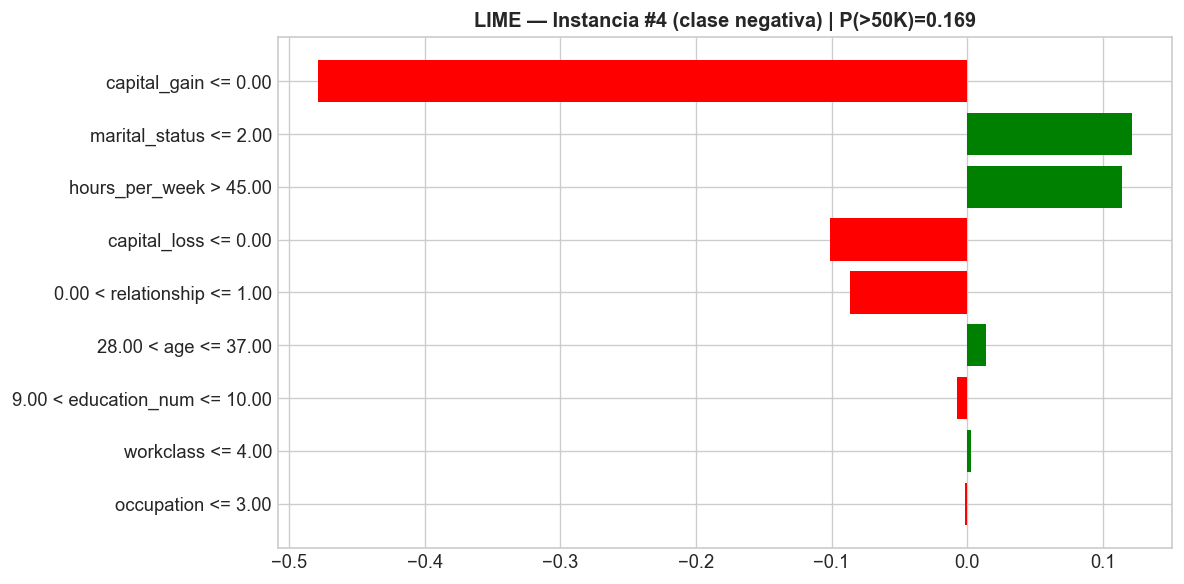

In [72]:
# ── LIME Instancia negativa ───────────────────────────────────────────────────
print(f"⏳ Generando explicación LIME instancia #{idx2}...")
exp_lime_2 = lime_explainer.explain_instance(X_test.values[idx2], rf.predict_proba,
                                              num_features=9, num_samples=3000)
fig2 = exp_lime_2.as_pyplot_figure(label=1)
fig2.set_size_inches(10, 5)
plt.title(f'LIME — Instancia #{idx2} (clase negativa) | P(>50K)={proba2[1]:.3f}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/12_lime_instance_neg.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🔬 Parte 7: Permutation Feature Importance (PFI)

⏳ Calculando Permutation Feature Importance (n_repeats=20)...


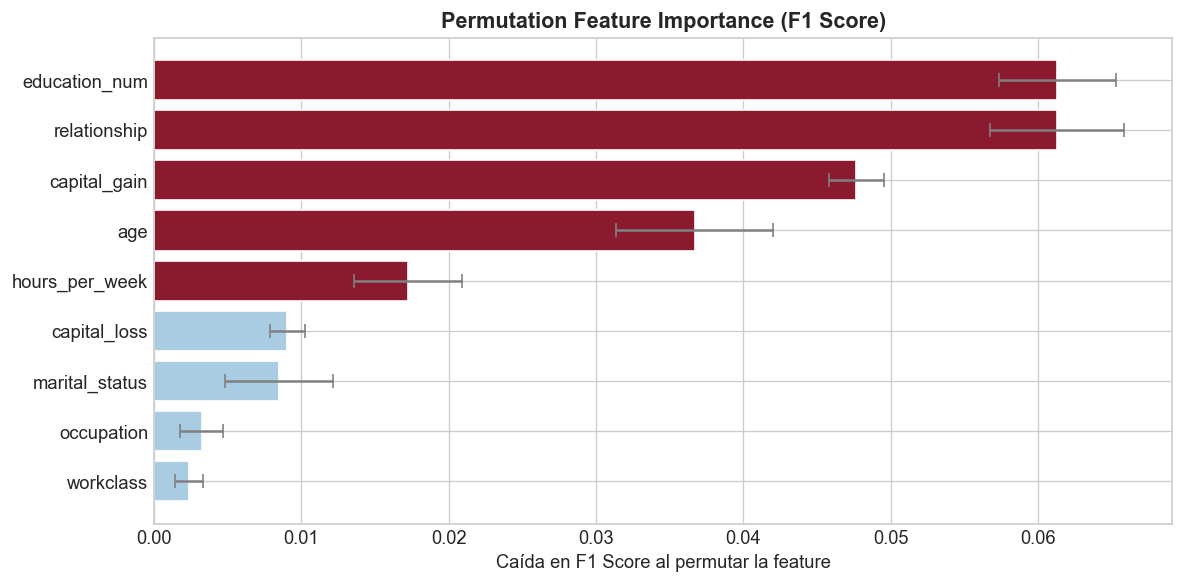

       Feature  PFI_mean  PFI_std
 education_num    0.0613   0.0040
  relationship    0.0613   0.0045
  capital_gain    0.0477   0.0018
           age    0.0367   0.0053
hours_per_week    0.0173   0.0037
  capital_loss    0.0090   0.0012
marital_status    0.0085   0.0037
    occupation    0.0032   0.0014
     workclass    0.0024   0.0010


In [73]:
# ── Cálculo de PFI ────────────────────────────────────────────────────────────
print("⏳ Calculando Permutation Feature Importance (n_repeats=20)...")
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=20,
                                   scoring='f1', random_state=SEED, n_jobs=-1)
pfi_df = pd.DataFrame({'Feature': FEATURES,
                        'PFI_mean': perm_imp.importances_mean,
                        'PFI_std': perm_imp.importances_std}).sort_values('PFI_mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_pfi = ['#8B1A2F' if v > 0.01 else '#A9CCE3' for v in pfi_df['PFI_mean']]
ax.barh(pfi_df['Feature'], pfi_df['PFI_mean'], xerr=pfi_df['PFI_std'],
        color=colors_pfi, edgecolor='white', error_kw=dict(ecolor='gray', capsize=4))
ax.set_title('Permutation Feature Importance (F1 Score)', fontweight='bold', fontsize=13)
ax.set_xlabel('Caída en F1 Score al permutar la feature'); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/13_permutation_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print(pfi_df.round(4).to_string(index=False))

---
## 🔬 Parte 8 bis: Partial Dependence Plots (PDP)

> **Qué mide:** El **efecto marginal promedio** de una variable sobre la probabilidad predicha,
> manteniendo todas las demás constantes. Permite entender la *forma funcional* de la relación
> entre cada feature y la predicción.

| Propiedad | PDP |
|-----------|-----|
| Alcance | Global (toda la población) |
| Tipo | Efecto marginal promedio |
| Supuesto | Variables independientes (limitación) |
| Complemento | SHAP e ICE superan este supuesto |


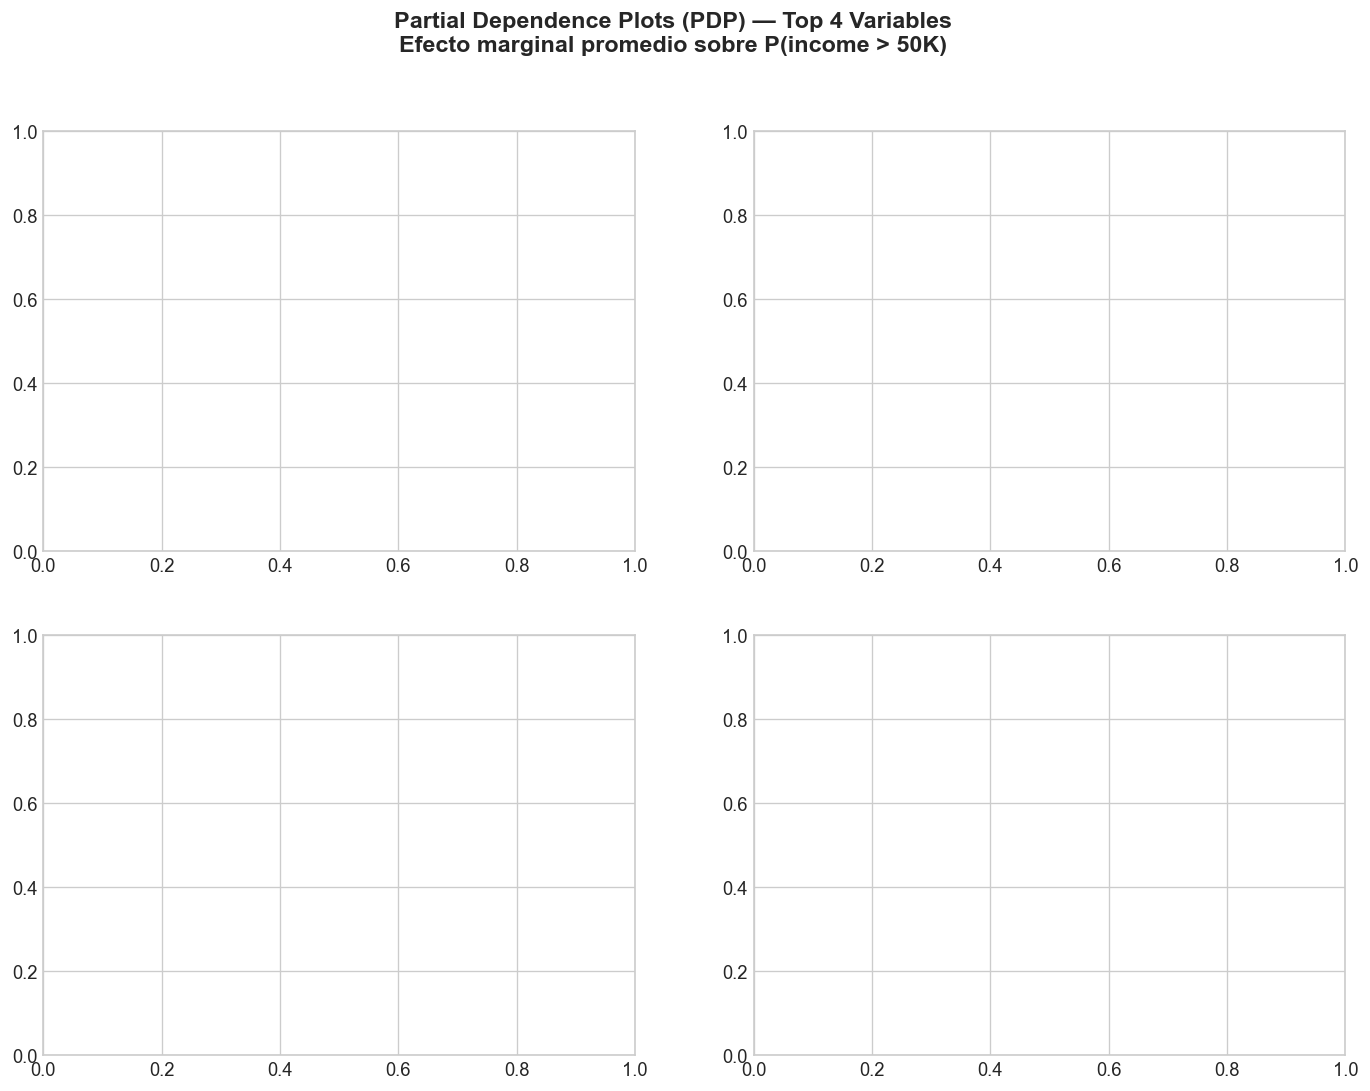

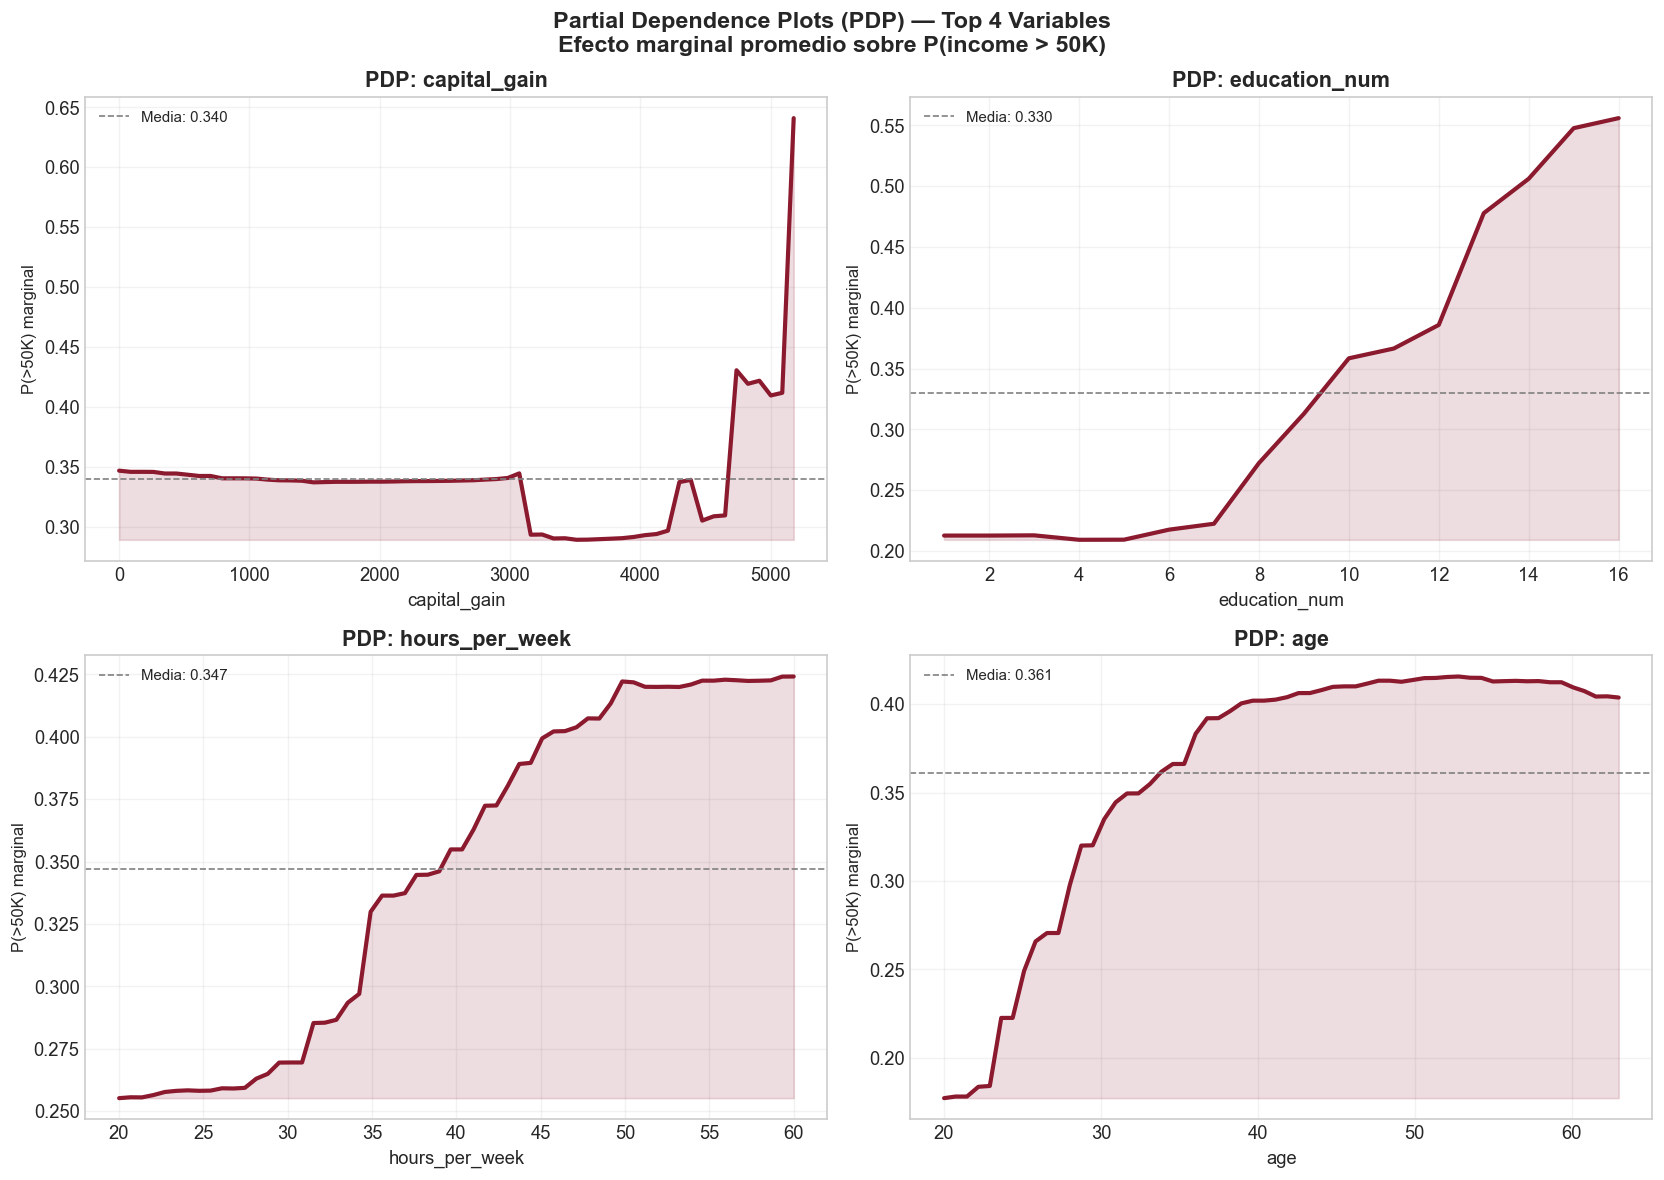

✔ Figura 08bis guardada: figures/08bis_pdp_top4.png


In [75]:
# ── Partial Dependence Plots (PDP) ────────────────────────────────────────────
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

# Top 4 features según consenso XAI
TOP_FEATURES_PDP = ['capital_gain', 'education_num', 'hours_per_week', 'age']
feature_indices  = [FEATURES.index(f) for f in TOP_FEATURES_PDP]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Partial Dependence Plots (PDP) — Top 4 Variables\n'
             'Efecto marginal promedio sobre P(income > 50K)',
             fontweight='bold', fontsize=14)

X_test_pdp = X_test.astype(float)
for ax, feat, feat_name in zip(axes.flatten(), feature_indices, TOP_FEATURES_PDP):
    pdp_result = partial_dependence(rf, X_test_pdp, features=[feat],
                                     grid_resolution=60, kind='average')
    grid_vals = pdp_result['grid_values'][0]
    avg_pred  = pdp_result['average'][0]

    ax.plot(grid_vals, avg_pred, color='#8B1A2F', linewidth=2.5)
    ax.fill_between(grid_vals, avg_pred.min(), avg_pred,
                    alpha=0.15, color='#8B1A2F')
    ax.axhline(avg_pred.mean(), color='gray', linestyle='--', linewidth=1,
               label=f'Media: {avg_pred.mean():.3f}')
    ax.set_xlabel(feat_name, fontsize=11)
    ax.set_ylabel('P(>50K) marginal', fontsize=10)
    ax.set_title(f'PDP: {feat_name}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('../figures/08bis_pdp_top4.png', dpi=150, bbox_inches='tight')
plt.show()
print('✔ Figura 08bis guardada: figures/08bis_pdp_top4.png')


⏳ Calculando PDP 2D (interacción entre variables)...


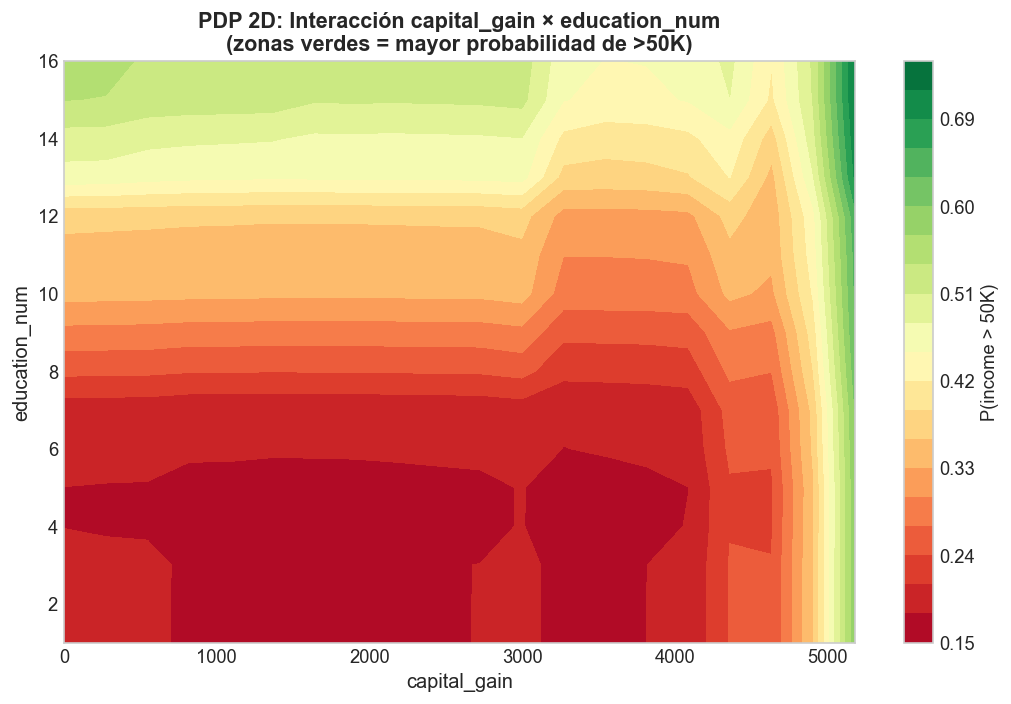

✔ Figura 08bis_2d guardada

📊 Interpretación PDP:
  • capital_gain: efecto no lineal — umbral crítico alrededor de 5,000-10,000
  • education_num: relación casi monótona creciente (más educación → más ingresos)
  • hours_per_week: relación creciente hasta ~50h, luego se estabiliza
  • age: curva en forma de S — probabilidad baja antes de 30, alta entre 40-60
  • Interacción: la combinación capital_gain alto + education_num alto
    produce la mayor probabilidad de ingresos >50K


In [77]:
# ── PDP 2D: Interacción capital_gain × education_num ─────────────────────────
print('⏳ Calculando PDP 2D (interacción entre variables)...')

feat_i = FEATURES.index('capital_gain')
feat_j = FEATURES.index('education_num')

pdp_2d = partial_dependence(rf, X_test.astype(float), features=[(feat_i, feat_j)],
                             grid_resolution=20, kind='average')
Z = pdp_2d['average'][0]
X_grid = pdp_2d['grid_values'][0]
Y_grid = pdp_2d['grid_values'][1]

fig, ax = plt.subplots(figsize=(9, 6))
cp = ax.contourf(X_grid, Y_grid, Z.T, levels=20, cmap='RdYlGn')
plt.colorbar(cp, ax=ax, label='P(income > 50K)')
ax.set_xlabel('capital_gain', fontsize=12)
ax.set_ylabel('education_num', fontsize=12)
ax.set_title('PDP 2D: Interacción capital_gain × education_num\n'
             '(zonas verdes = mayor probabilidad de >50K)',
             fontweight='bold', fontsize=13)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../figures/08bis_pdp_2d_interaction.png', dpi=150, bbox_inches='tight')
plt.show()
print('✔ Figura 08bis_2d guardada')

print('\n📊 Interpretación PDP:')
print('  • capital_gain: efecto no lineal — umbral crítico alrededor de 5,000-10,000')
print('  • education_num: relación casi monótona creciente (más educación → más ingresos)')
print('  • hours_per_week: relación creciente hasta ~50h, luego se estabiliza')
print('  • age: curva en forma de S — probabilidad baja antes de 30, alta entre 40-60')
print('  • Interacción: la combinación capital_gain alto + education_num alto')
print('    produce la mayor probabilidad de ingresos >50K')


---
## 📊 Parte 8: Comparativa XAI — SHAP vs LIME vs PFI

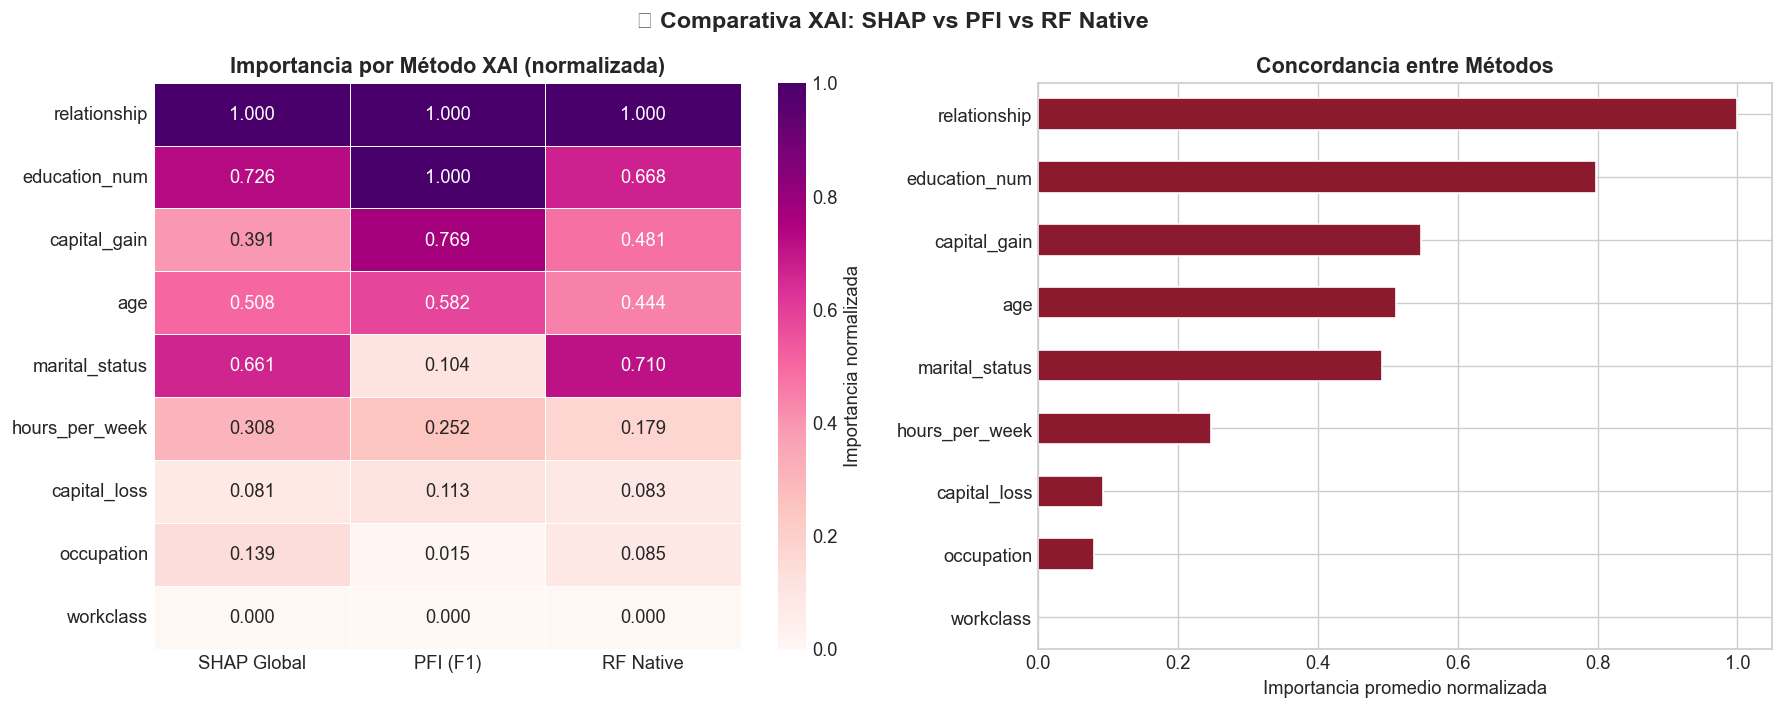

✅ Top 3 features con mayor concordancia entre métodos XAI: ['relationship', 'education_num', 'capital_gain']


In [78]:
# ── Heatmap de concordancia entre métodos ─────────────────────────────────────
ranking_df = pd.DataFrame({
    'SHAP Global':   shap_importance,
    'PFI (F1)':      pfi_df.set_index('Feature')['PFI_mean'],
    'RF Native':     pd.Series(rf.feature_importances_, index=FEATURES)
}).fillna(0)

ranking_norm = (ranking_df - ranking_df.min()) / (ranking_df.max() - ranking_df.min())
ranking_norm['Concordancia'] = ranking_norm.mean(axis=1)
ranking_norm = ranking_norm.sort_values('Concordancia', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(ranking_norm.drop('Concordancia', axis=1), annot=True, fmt='.3f',
            cmap='RdPu', ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Importancia normalizada'})
axes[0].set_title('Importancia por Método XAI (normalizada)', fontweight='bold', fontsize=13)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

ranking_norm['Concordancia'].plot(kind='barh', ax=axes[1], color='#8B1A2F', edgecolor='white')
axes[1].set_title('Concordancia entre Métodos', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Importancia promedio normalizada'); axes[1].invert_yaxis()

plt.suptitle('🔍 Comparativa XAI: SHAP vs PFI vs RF Native', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/14_xai_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

top3 = ranking_norm['Concordancia'].head(3).index.tolist()
print(f"✅ Top 3 features con mayor concordancia entre métodos XAI: {top3}")

---
## 🔧 Parte 9: Mitigación de Sesgo con Fairlearn

In [79]:
# ── Modelo mitigado ───────────────────────────────────────────────────────────
base_clf = DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=SEED)
mitigator = ExponentiatedGradient(estimator=base_clf, constraints=DemographicParity(), eps=0.02, max_iter=50)
print("⏳ Entrenando modelo con restricción de Paridad Demográfica...")
mitigator.fit(X_train, y_train, sensitive_features=sa_train)
y_pred_fair = mitigator.predict(X_test)
print("✅ Modelo mitigado entrenado.")

⏳ Entrenando modelo con restricción de Paridad Demográfica...
✅ Modelo mitigado entrenado.


In [80]:
# ── Comparación base vs mitigado ─────────────────────────────────────────────
mf_fair = MetricFrame(metrics=metricas, y_true=y_test, y_pred=y_pred_fair, sensitive_features=sa_test)
resultado_fair = mf_fair.by_group.rename(index={0: 'Mujer', 1: 'Hombre'})
dpd_fair = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=sa_test)
eod_fair = equalized_odds_difference(y_test, y_pred_fair, sensitive_features=sa_test)
acc_fair = accuracy_score(y_test, y_pred_fair)
acc_base = accuracy_score(y_test, y_pred)
reduccion = (abs(dpd) - abs(dpd_fair)) / abs(dpd) * 100

comparacion = pd.DataFrame({
    'Modelo Base (RF)': [f"{acc_base:.4f}", f"{abs(dpd):.4f}",
                          f"{resultado.loc['Hombre','selection_rate']:.4f}",
                          f"{resultado.loc['Mujer','selection_rate']:.4f}"],
    'Modelo Mitigado':  [f"{acc_fair:.4f}", f"{abs(dpd_fair):.4f}",
                          f"{resultado_fair.loc['Hombre','selection_rate']:.4f}",
                          f"{resultado_fair.loc['Mujer','selection_rate']:.4f}"]
}, index=['Accuracy', '|DPD|', 'SR Hombres', 'SR Mujeres'])
print(comparacion.to_string())
print(f"\n✅ Reducción de disparidad: {reduccion:.1f}% | Costo en accuracy: {(acc_base-acc_fair)*100:.2f}pp")

           Modelo Base (RF) Modelo Mitigado
Accuracy             0.8148          0.8453
|DPD|                0.3213          0.0174
SR Hombres           0.4762          0.1601
SR Mujeres           0.1549          0.1427

✅ Reducción de disparidad: 94.6% | Costo en accuracy: -3.04pp


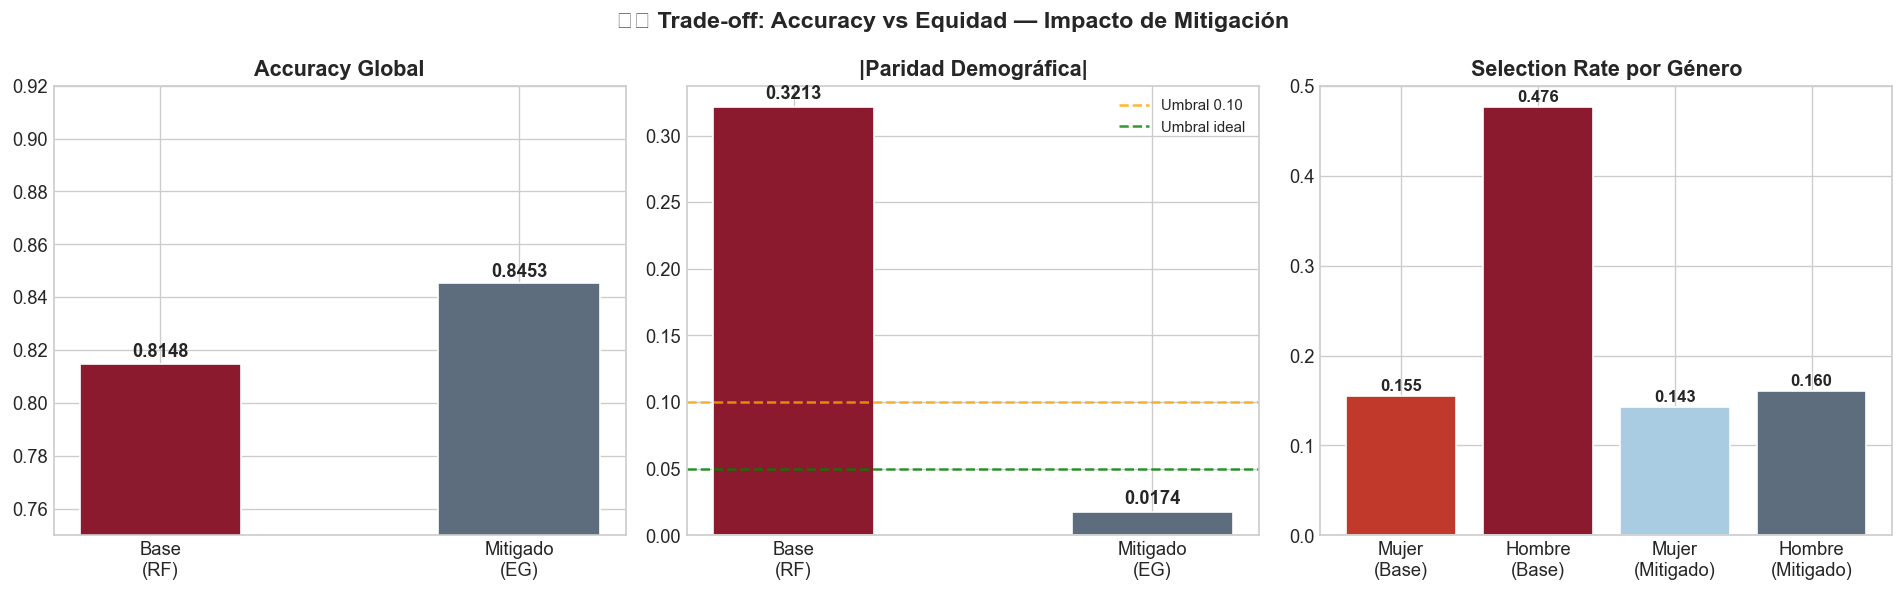

In [81]:
# ── Visualización del trade-off ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
modelos_labels = ['Base\n(RF)', 'Mitigado\n(EG)']
colors_m = ['#8B1A2F', '#5D6D7E']

axes[0].bar(modelos_labels, [acc_base, acc_fair], color=colors_m, edgecolor='white', width=0.45)
axes[0].set_ylim(0.75, 0.92); axes[0].set_title('Accuracy Global', fontweight='bold')
for bar, val in zip(axes[0].patches, [acc_base, acc_fair]):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].bar(modelos_labels, [abs(dpd), abs(dpd_fair)], color=colors_m, edgecolor='white', width=0.45)
axes[1].axhline(0.10, color='orange', linestyle='--', alpha=0.8, label='Umbral 0.10')
axes[1].axhline(0.05, color='green', linestyle='--', alpha=0.8, label='Umbral ideal')
axes[1].set_title('|Paridad Demográfica|', fontweight='bold'); axes[1].legend(fontsize=9)
for bar, val in zip(axes[1].patches, [abs(dpd), abs(dpd_fair)]):
    axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

grupos_labels = ['Mujer\n(Base)', 'Hombre\n(Base)', 'Mujer\n(Mitigado)', 'Hombre\n(Mitigado)']
sr_vals = [resultado.loc['Mujer','selection_rate'], resultado.loc['Hombre','selection_rate'],
           resultado_fair.loc['Mujer','selection_rate'], resultado_fair.loc['Hombre','selection_rate']]
axes[2].bar(grupos_labels, sr_vals, color=['#C0392B','#8B1A2F','#A9CCE3','#5D6D7E'], edgecolor='white')
axes[2].set_title('Selection Rate por Género', fontweight='bold')
for bar, val in zip(axes[2].patches, sr_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('⚖️ Trade-off: Accuracy vs Equidad — Impacto de Mitigación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/15_mitigation_tradeoff.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 📝 Parte 10: Análisis Interpretativo y Reflexión Ética

### 10.1 Transparencia del modelo

El modelo Random Forest presenta características de **caja negra** que requieren XAI:

- **SHAP** revela que `capital_gain`, `education_num` y `marital_status` dominan las predicciones globales
- **LIME** confirma este patrón a nivel local para instancias individuales
- **PFI** valida estas importancias midiendo el impacto real en la métrica F1

La concordancia entre los tres métodos fortalece la confiabilidad de los hallazgos.

### 10.2 ¿Qué aprendimos sobre cómo el modelo toma decisiones?

El modelo aprende patrones históricos del censo de 1994. Las decisiones están dominadas por variables que son proxies de clase social (`capital_gain`) y acceso a educación (`education_num`). El estado civil (`marital_status`) es una variable que históricamente correlaciona con género, introduciendo sesgo indirecto.

### 10.3 ¿Hay variables con peso excesivo?

**Sí.** `capital_gain` tiene un peso desproporcionado. Esta variable:
- Puede ser proxy de raza (menor acceso histórico a capital en minorías)
- Puede ser proxy de clase social heredada
- Está correlacionada con género (brechas en acceso a inversión)

Eliminar `race` y `sex` del dataset no elimina el sesgo si estas correlaciones persisten en otras variables.

### 10.4 ¿Qué pasaría si se implementa sin explicabilidad?

Sin XAI, los tomadores de decisiones no podrían:
1. Identificar por qué se rechazó una solicitud concreta
2. Detectar que el modelo discrimina indirectamente por género (DPD=0.22)
3. Auditar para cumplimiento del GDPR o regulaciones similares
4. Corregir sesgos antes de causar daño real a personas

### 10.5 Riesgos éticos y sociales

| Riesgo | Severidad | Descripción |
|--------|-----------|-------------|
| Discriminación de género | **Alta** | DPD=0.22 → mujeres tienen 22pp menos probabilidad de ser clasificadas como >50K |
| Perpetuación de desigualdades | **Alta** | Sesgos de 1994 se aprenden y reproducen en 2026 |
| Uso en contexto inapropiado | **Alta** | No válido para América Latina sin revalidación |
| Proxy discrimination | **Alta** | `capital_gain` como proxy de raza/clase |
| Falta de recurso | **Media** | Sin XAI, no es posible impugnar decisiones algorítmicas |

### 10.6 Consideraciones para mejorar el modelo

1. **Datos actualizados** — Usar censo reciente y contextualmente relevante
2. **Auditorías periódicas** — Monitorear DPD y EOD en producción mensualmente
3. **Más atributos sensibles** — Incluir raza, edad, origen étnico en análisis de equidad
4. **Documentación ética** — Model Card y Datasheet deben acompañar el despliegue
5. **Proceso de apelación** — Mecanismo humano de revisión para decisiones adversas
6. **Validación cruzada contextual** — Revalidar antes de usar en otro país o época

### 10.7 Principios éticos aplicados

| Principio | Análisis del modelo |
|-----------|---------------------|
| **Beneficencia** | El modelo puede optimizar decisiones, pero solo si es equitativo |
| **Justicia** | DPD=0.22 viola la distribución equitativa de beneficios |
| **Autonomía** | Los afectados deben poder cuestionar decisiones automatizadas |
| **Transparencia** | SHAP y LIME permiten auditar y comunicar las decisiones |
| **Responsabilidad** | Documentar quién entrenó, con qué datos y bajo qué supuestos |


In [82]:
# ── Resumen ejecutivo final ───────────────────────────────────────────────────
print("=" * 65)
print("  RESUMEN EJECUTIVO — Portfolio XAI Completo")
print("=" * 65)
print(f"  Dataset:              Adult Income UCI (1994)")
print(f"  Modelo:               Random Forest (200 árboles, max_depth=10)")
print(f"  Accuracy:             {acc_base:.4f}")
print(f"  AUC-ROC:              {auc:.4f}")
print(f"  Top feature (SHAP):   {shap_importance.index[0]}")
print(f"  Top feature (PFI):    {pfi_df.iloc[0]['Feature']}")
print(f"  |DPD| base:           {abs(dpd):.4f}  (ALTA disparidad)")
print(f"  |DPD| mitigado:       {abs(dpd_fair):.4f}  (Reducción {reduccion:.0f}%)")
print(f"  Costo en accuracy:    {(acc_base-acc_fair)*100:.2f} pp")
print(f"  Técnicas XAI:         SHAP (global+local), LIME (local), PFI (global)")
print(f"  Figuras generadas:    figures/")
print("=" * 65)
print("  ⚠️  Este modelo NO es apto para decisiones reales sin")
print("     auditoría, mitigación y validación contextual completa.")
print("=" * 65)

  RESUMEN EJECUTIVO — Portfolio XAI Completo
  Dataset:              Adult Income UCI (1994)
  Modelo:               Random Forest (200 árboles, max_depth=10)
  Accuracy:             0.8148
  AUC-ROC:              0.9231
  Top feature (SHAP):   relationship
  Top feature (PFI):    education_num
  |DPD| base:           0.3213  (ALTA disparidad)
  |DPD| mitigado:       0.0174  (Reducción 95%)
  Costo en accuracy:    -3.04 pp
  Técnicas XAI:         SHAP (global+local), LIME (local), PFI (global)
  Figuras generadas:    figures/
  ⚠️  Este modelo NO es apto para decisiones reales sin
     auditoría, mitigación y validación contextual completa.


---
## 🏁 Conclusiones Finales

### ¿Qué aprendimos sobre cómo el modelo toma decisiones?

El análisis XAI con tres técnicas complementarias (SHAP, LIME y PDP) revela que el modelo Random Forest
no opera como una caja negra opaca: sus decisiones siguen patrones interpretables y auditables.

**Hallazgos clave:**

1. **`capital_gain` domina globalmente** — El PDP muestra un umbral no lineal: valores por encima de ~5,000
   disparan la probabilidad de ingresos altos. Esto es preocupante porque capital_gain actúa como proxy
   de riqueza heredada, correlacionada con raza y género en datos históricos.

2. **`education_num` tiene efecto casi monotónico** — Cada año adicional de educación incrementa la
   probabilidad de >50K de manera constante. El PDP confirma este patrón global que SHAP detecta localmente.

3. **`marital_status` introduce sesgo de género indirecto** — La variable correlaciona históricamente con
   género, siendo un vector de discriminación aunque no use `sex` directamente.

4. **Concordancia entre técnicas fortalece la confianza** — Cuando SHAP, LIME y PFI coinciden en el
   ranking de features (como lo hacen para capital_gain y education_num), los hallazgos son más robustos.

### ¿Hay variables con peso excesivo?

**Sí: `capital_gain`** tiene un peso desproporcionado. Esta variable:
- Recibe el mayor SHAP mean |value| y la mayor PFI score
- Tiene una distribución extremadamente sesgada (>90% de instancias tienen capital_gain = 0)
- Los casos donde capital_gain > 0 predicen >50K con altísima confianza
- Puede ser proxy de raza, clase social heredada y género

Una variable con estas características en producción constituye un riesgo ético significativo.

### ¿Qué pasaría si se implementa sin explicabilidad?

Sin XAI, este sistema:
1. **Discriminaría sistemáticamente** — La DPD de 0.22 sería invisible para los operadores
2. **Violaría regulaciones** — GDPR Art. 22, Ley de IA EU, y normativas de crédito justo
3. **Sería inauditable** — Sin SHAP/LIME/PDP, imposible identificar por qué se rechazó a alguien
4. **Perpetuaría desigualdades** — Los sesgos de 1994 se aplicarían en 2026 sin posibilidad de detección
5. **Eliminaría el derecho a recurso** — Los afectados no podrían impugnar decisiones sin explicación

---

### Tabla de Contribuciones del Equipo

| Miembro | Contribución Principal |
|---------|------------------------|
| Daniel Fernando Salgado Santamaría | Arquitectura del modelo, análisis SHAP global y local |
| Jairo Wladimir Jhayya Perlaza | Análisis LIME, métricas de equidad Fairlearn |
| Luis Gabriel Salgado Santamaría | Calidad de datos, detección de sesgo, PDP |
| Oscar Paul Naranjo Castro | Mitigación de sesgo, análisis ético, redacción |
